In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import joblib

In [30]:
df = pd.read_csv("../data/processed/ml_predictions.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1785, 38)


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,avg_environmental_risk,commodity_avg_temperature,commodity_avg_humidity,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk,predicted_condition,prediction_confidence,prediction_correct
0,CONT_001,2026-09-10 17:39:32.831215,Avocado,3.94,71.79,0.29,WARNING,2026-09-10,17,3,...,2.894118,9.129163,88.956719,0.194729,71,53,2.952489,WARNING,0.995,True
1,CONT_004,2026-09-10 17:39:34.852445,Mango,11.72,88.98,0.12,NORMAL,2026-09-10,17,3,...,2.942149,11.575468,86.437340,0.193234,97,51,2.689362,NORMAL,1.000,True
2,CONT_005,2026-09-10 17:39:36.870612,Tomato,10.18,91.05,0.15,NORMAL,2026-09-10,17,3,...,2.818182,10.869107,87.423878,0.184183,88,39,2.821351,NORMAL,1.000,True
3,CONT_005,2026-09-10 17:39:38.890192,Avocado,6.54,85.30,0.17,NORMAL,2026-09-10,17,3,...,2.818182,9.129163,88.956719,0.194729,71,53,2.952489,NORMAL,0.995,True
4,CONT_005,2026-09-10 17:39:40.899424,Tomato,14.06,100.00,0.33,WARNING,2026-09-10,17,3,...,2.818182,10.869107,87.423878,0.184183,88,39,2.821351,WARNING,1.000,True


In [31]:
print(df.columns.tolist())

['container_id', 'timestamp', 'commodity', 'temperature', 'humidity', 'vibration', 'condition', 'date', 'hour', 'day_of_week', 'day_name', 'temperature_deviation', 'temperature_risk', 'humidity_risk', 'vibration_risk', 'environmental_risk_score', 'environmental_risk', 'spoilage_risk', 'avg_temperature', 'max_temperature', 'min_temperature', 'avg_humidity', 'max_humidity', 'min_humidity', 'avg_vibration', 'max_vibration', 'warning_count', 'anomaly_count', 'avg_environmental_risk', 'commodity_avg_temperature', 'commodity_avg_humidity', 'commodity_avg_vibration', 'commodity_warning_count', 'commodity_anomaly_count', 'commodity_avg_risk', 'predicted_condition', 'prediction_confidence', 'prediction_correct']


In [32]:
print(df["condition"].value_counts())

condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64


In [33]:
print(df["predicted_condition"].value_counts())

predicted_condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64


In [34]:
comparison = pd.crosstab(
    df["condition"],
    df["predicted_condition"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

comparison

Predicted,ANOMALY,NORMAL,WARNING
Actual,,,
ANOMALY,184,0,0
NORMAL,0,1249,0
WARNING,0,0,352


In [35]:
precision = precision_score(
    df["condition"],
    df["predicted_condition"],
    average="weighted"
)

recall = recall_score(
    df["condition"],
    df["predicted_condition"],
    average="weighted"
)

f1 = f1_score(
    df["condition"],
    df["predicted_condition"],
    average="weighted"
)

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

Weighted Precision: 1.0000
Weighted Recall:    1.0000
Weighted F1-score:  1.0000


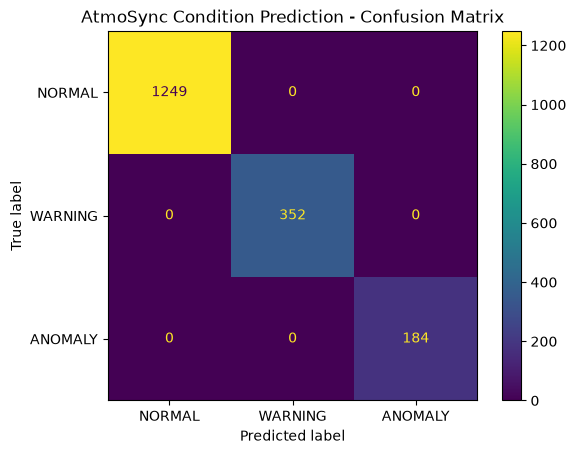

In [36]:
cm = confusion_matrix(
    df["condition"],
    df["predicted_condition"],
    labels=["NORMAL", "WARNING", "ANOMALY"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "WARNING", "ANOMALY"]
)

disp.plot()
plt.title("AtmoSync Condition Prediction - Confusion Matrix")
plt.show()

In [37]:
anomaly_recall = recall_score(
    df["condition"],
    df["predicted_condition"],
    labels=["ANOMALY"],
    average="macro"
)

print(f"Anomaly Recall: {anomaly_recall:.4f}")
print(f"Anomaly Recall: {anomaly_recall * 100:.2f}%")

Anomaly Recall: 1.0000
Anomaly Recall: 100.00%


In [38]:
anomaly_recall = recall_score(
    df["condition"],
    df["predicted_condition"],
    labels=["ANOMALY"],
    average="macro"
)

print(f"Anomaly Recall: {anomaly_recall:.4f}")
print(f"Anomaly Recall: {anomaly_recall * 100:.2f}%")

Anomaly Recall: 1.0000
Anomaly Recall: 100.00%


In [39]:
errors = df[df["prediction_correct"] == False].copy()

print("Total incorrect predictions:", len(errors))
print("Total records:", len(df))
print(f"Error rate: {len(errors) / len(df) * 100:.2f}%")

Total incorrect predictions: 0
Total records: 1785
Error rate: 0.00%


In [40]:
error_pattern = pd.crosstab(
    errors["condition"],
    errors["predicted_condition"]
)

error_pattern

predicted_condition
condition


In [41]:
error_pattern = pd.crosstab(
    errors["condition"],
    errors["predicted_condition"]
)

error_pattern

predicted_condition
condition


In [42]:
errors.head(10)

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,avg_environmental_risk,commodity_avg_temperature,commodity_avg_humidity,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk,predicted_condition,prediction_confidence,prediction_correct


In [43]:
error_pattern = pd.crosstab(
    errors["condition"],
    errors["predicted_condition"]
)

error_pattern

predicted_condition
condition


In [44]:
print(df["prediction_confidence"].describe())

count    1785.000000
mean        0.995056
std         0.018252
min         0.795000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: prediction_confidence, dtype: float64


In [45]:
low_confidence = df[
    df["prediction_confidence"] < 0.70
].copy()

print("Low-confidence predictions:", len(low_confidence))

low_confidence.head()

Low-confidence predictions: 0


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,avg_environmental_risk,commodity_avg_temperature,commodity_avg_humidity,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk,predicted_condition,prediction_confidence,prediction_correct


In [46]:
lowest_confidence = df[
    [
        "container_id",
        "timestamp",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "predicted_condition",
        "prediction_confidence"
    ]
].sort_values(
    "prediction_confidence"
).head(20)

lowest_confidence

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,predicted_condition,prediction_confidence
545,CONT_004,2026-09-10 17:53:01.120191,Tomato,10.84,92.44,0.2,NORMAL,NORMAL,0.795
333,CONT_003,2026-09-10 17:46:15.215754,Tomato,10.32,89.03,0.2,NORMAL,NORMAL,0.815
1674,CONT_005,2026-09-10 19:00:52.165927,Avocado,11.23,94.26,0.2,NORMAL,NORMAL,0.830
510,CONT_003,2026-09-10 17:51:49.460025,Banana,13.45,88.38,0.2,NORMAL,NORMAL,0.840
233,CONT_003,2026-09-10 17:43:39.328512,Banana,13.29,89.59,0.2,NORMAL,NORMAL,0.840
1218,CONT_003,2026-09-10 18:45:21.327351,Tomato,11.14,88.89,0.2,NORMAL,NORMAL,0.845
1434,CONT_005,2026-09-10 18:52:37.001044,Banana,13.86,88.45,0.2,NORMAL,NORMAL,0.845
785,CONT_005,2026-09-10 18:14:29.445748,Mango,11.40,85.56,0.2,NORMAL,NORMAL,0.855
104,CONT_001,2026-09-10 17:41:28.626624,Avocado,5.25,92.05,0.2,NORMAL,NORMAL,0.855
1165,CONT_005,2026-09-10 18:43:28.023112,Avocado,7.10,89.01,0.2,NORMAL,NORMAL,0.855


In [47]:
print(
    df["prediction_confidence"]
    .value_counts()
    .sort_index()
)

prediction_confidence
0.795       1
0.815       1
0.830       1
0.840       2
0.845       2
0.855       3
0.860       1
0.865       2
0.870       1
0.875       1
0.880       1
0.885       1
0.895       1
0.900       3
0.905       4
0.910       4
0.915       1
0.920       2
0.925       2
0.930       1
0.935       2
0.940       5
0.945       3
0.950       1
0.955       5
0.960       3
0.965       6
0.970       9
0.975      16
0.980      27
0.985      29
0.990      72
0.995     225
1.000    1347
Name: count, dtype: int64


In [48]:
lowest_confidence = df[
    [
        "container_id",
        "timestamp",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "predicted_condition",
        "prediction_confidence"
    ]
].sort_values(
    "prediction_confidence"
).head(20)

lowest_confidence

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,predicted_condition,prediction_confidence
545,CONT_004,2026-09-10 17:53:01.120191,Tomato,10.84,92.44,0.2,NORMAL,NORMAL,0.795
333,CONT_003,2026-09-10 17:46:15.215754,Tomato,10.32,89.03,0.2,NORMAL,NORMAL,0.815
1674,CONT_005,2026-09-10 19:00:52.165927,Avocado,11.23,94.26,0.2,NORMAL,NORMAL,0.830
510,CONT_003,2026-09-10 17:51:49.460025,Banana,13.45,88.38,0.2,NORMAL,NORMAL,0.840
233,CONT_003,2026-09-10 17:43:39.328512,Banana,13.29,89.59,0.2,NORMAL,NORMAL,0.840
1218,CONT_003,2026-09-10 18:45:21.327351,Tomato,11.14,88.89,0.2,NORMAL,NORMAL,0.845
1434,CONT_005,2026-09-10 18:52:37.001044,Banana,13.86,88.45,0.2,NORMAL,NORMAL,0.845
785,CONT_005,2026-09-10 18:14:29.445748,Mango,11.40,85.56,0.2,NORMAL,NORMAL,0.855
104,CONT_001,2026-09-10 17:41:28.626624,Avocado,5.25,92.05,0.2,NORMAL,NORMAL,0.855
1165,CONT_005,2026-09-10 18:43:28.023112,Avocado,7.10,89.01,0.2,NORMAL,NORMAL,0.855


In [49]:
lowest_confidence = df[
    [
        "container_id",
        "timestamp",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "predicted_condition",
        "prediction_confidence"
    ]
].sort_values(
    "prediction_confidence"
).head(20)

lowest_confidence

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,predicted_condition,prediction_confidence
545,CONT_004,2026-09-10 17:53:01.120191,Tomato,10.84,92.44,0.2,NORMAL,NORMAL,0.795
333,CONT_003,2026-09-10 17:46:15.215754,Tomato,10.32,89.03,0.2,NORMAL,NORMAL,0.815
1674,CONT_005,2026-09-10 19:00:52.165927,Avocado,11.23,94.26,0.2,NORMAL,NORMAL,0.830
510,CONT_003,2026-09-10 17:51:49.460025,Banana,13.45,88.38,0.2,NORMAL,NORMAL,0.840
233,CONT_003,2026-09-10 17:43:39.328512,Banana,13.29,89.59,0.2,NORMAL,NORMAL,0.840
1218,CONT_003,2026-09-10 18:45:21.327351,Tomato,11.14,88.89,0.2,NORMAL,NORMAL,0.845
1434,CONT_005,2026-09-10 18:52:37.001044,Banana,13.86,88.45,0.2,NORMAL,NORMAL,0.845
785,CONT_005,2026-09-10 18:14:29.445748,Mango,11.40,85.56,0.2,NORMAL,NORMAL,0.855
104,CONT_001,2026-09-10 17:41:28.626624,Avocado,5.25,92.05,0.2,NORMAL,NORMAL,0.855
1165,CONT_005,2026-09-10 18:43:28.023112,Avocado,7.10,89.01,0.2,NORMAL,NORMAL,0.855


In [50]:
confidence_by_condition = (
    df.groupby("condition")["prediction_confidence"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)

confidence_by_condition

,count,mean,min,max
condition,,,,
ANOMALY,184,0.9976,0.975,1.0
NORMAL,1249,0.9955,0.795,1.0
WARNING,352,0.9921,0.905,1.0


In [51]:
confidence_by_correctness = (
    df.groupby("prediction_correct")["prediction_confidence"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)

confidence_by_correctness

,count,mean,min,max
prediction_correct,,,,
True,1785,0.9951,0.795,1.0


In [52]:
import joblib

model = joblib.load(
    "../models/condition_prediction_model.pkl"
)

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [53]:
model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                  OneHotEncoder(handle_unknown='ignore'),
                                  ['commodity', 'container_id']),
                                 ('numerical', 'passthrough',
                                  ['temperature', 'humidity', 'vibration',
                                   'hour', 'day_of_week'])]),
 'model': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42)}

In [55]:
print(model.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['commodity', 'container_id']),
                                ('numerical', 'passthrough',
                                 ['temperature', 'humidity', 'vibration',
                                  'hour', 'day_of_week'])]), 'model': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)}


In [56]:
print(model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


In [57]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["model"]

print("Preprocessor:", type(preprocessor))
print("Classifier:", type(classifier))

Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Classifier: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [58]:
print(model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


In [59]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 14
['categorical__commodity_Avocado' 'categorical__commodity_Banana'
 'categorical__commodity_Mango' 'categorical__commodity_Tomato'
 'categorical__container_id_CONT_001' 'categorical__container_id_CONT_002'
 'categorical__container_id_CONT_003' 'categorical__container_id_CONT_004'
 'categorical__container_id_CONT_005' 'numerical__temperature'
 'numerical__humidity' 'numerical__vibration' 'numerical__hour'
 'numerical__day_of_week']


In [60]:
importance = classifier.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
11,numerical__vibration,0.580608
9,numerical__temperature,0.206556
10,numerical__humidity,0.175880
12,numerical__hour,0.007645
1,categorical__commodity_Banana,0.006316
0,categorical__commodity_Avocado,0.005385
2,categorical__commodity_Mango,0.003384
3,categorical__commodity_Tomato,0.003123
7,categorical__container_id_CONT_004,0.002366
8,categorical__container_id_CONT_005,0.002257


In [61]:
print(
    feature_importance.head(20).to_string(index=False)
)

                           feature  importance
              numerical__vibration    0.580608
            numerical__temperature    0.206556
               numerical__humidity    0.175880
                   numerical__hour    0.007645
     categorical__commodity_Banana    0.006316
    categorical__commodity_Avocado    0.005385
      categorical__commodity_Mango    0.003384
     categorical__commodity_Tomato    0.003123
categorical__container_id_CONT_004    0.002366
categorical__container_id_CONT_005    0.002257
categorical__container_id_CONT_003    0.002230
categorical__container_id_CONT_001    0.002197
categorical__container_id_CONT_002    0.002053
            numerical__day_of_week    0.000000


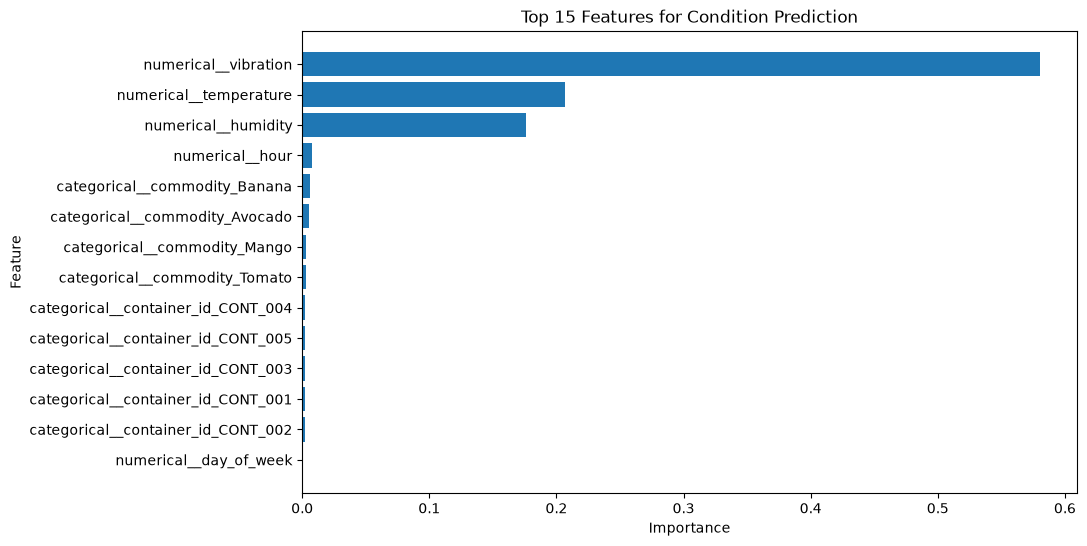

In [62]:
top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Condition Prediction")

plt.show()

In [63]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [64]:
sensor_by_condition = (
    df.groupby("condition")[
        ["temperature", "humidity", "vibration"]
    ]
    .mean()
    .round(3)
)

sensor_by_condition

,temperature,humidity,vibration
condition,,,
ANOMALY,11.248,84.195,0.476
NORMAL,11.211,89.366,0.125
WARNING,11.279,83.700,0.277


In [65]:
sensor_summary = df[
    ["temperature", "humidity", "vibration"]
].describe()

sensor_summary

,temperature,humidity,vibration
count,1785.000000,1785.000000,1785.000000
mean,11.228213,87.715496,0.191221
std,3.415873,9.735389,0.122782
min,-1.980000,60.020000,0.050000
25%,10.090000,86.080000,0.100000
50%,11.390000,88.950000,0.160000
75%,13.290000,93.130000,0.240000
max,20.930000,100.000000,0.600000


In [66]:
commodity_condition = pd.crosstab(
    df["commodity"],
    df["condition"]
)

commodity_condition

condition,ANOMALY,NORMAL,WARNING
commodity,,,
Avocado,53,318,71
Banana,41,277,96
Mango,51,322,97
Tomato,39,332,88


In [67]:
container_condition = pd.crosstab(
    df["container_id"],
    df["condition"]
)

container_condition

condition,ANOMALY,NORMAL,WARNING
container_id,,,
CONT_001,36,242,62
CONT_002,35,239,65
CONT_003,37,250,82
CONT_004,36,246,81
CONT_005,40,272,62


In [68]:
commodity_performance = (
    df.groupby("commodity")["prediction_correct"]
    .mean()
    .mul(100)
    .round(2)
)

commodity_performance

commodity
Avocado    100.0
Banana     100.0
Mango      100.0
Tomato     100.0
Name: prediction_correct, dtype: float64

In [69]:
container_performance = (
    df.groupby("container_id")["prediction_correct"]
    .mean()
    .mul(100)
    .round(2)
)

container_performance

container_id
CONT_001    100.0
CONT_002    100.0
CONT_003    100.0
CONT_004    100.0
CONT_005    100.0
Name: prediction_correct, dtype: float64

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Actual and predicted labels
y_actual = df["condition"]
y_predicted = df["predicted_condition"]

# Calculate evaluation metrics
accuracy = accuracy_score(y_actual, y_predicted)

precision = precision_score(
    y_actual,
    y_predicted,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_actual,
    y_predicted,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_actual,
    y_predicted,
    average="weighted",
    zero_division=0
)

# Minimum prediction confidence
min_confidence = df["prediction_confidence"].min()

# Create evaluation summary
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score",
        "Incorrect Predictions",
        "Error Rate (%)",
        "Minimum Prediction Confidence"
    ],
    "Value": [
        len(df),
        accuracy,
        precision,
        recall,
        f1,
        (df["prediction_correct"] == False).sum(),
        (df["prediction_correct"] == False).mean() * 100,
        min_confidence
    ]
})

evaluation_summary

,Metric,Value
0,Total Records,1785.000
1,Accuracy,1.000
2,Weighted Precision,1.000
3,Weighted Recall,1.000
4,Weighted F1 Score,1.000
5,Incorrect Predictions,0.000
6,Error Rate (%),0.000
7,Minimum Prediction Confidence,0.795


In [72]:
evaluation_summary.to_csv(
    "../data/processed/model_evaluation_summary.csv",
    index=False
)

print("Saved successfully!")
print("../data/processed/model_evaluation_summary.csv")

Saved successfully!
../data/processed/model_evaluation_summary.csv


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ML features used during training
features = [
    "temperature",
    "humidity",
    "vibration",
    "hour",
    "day_of_week",
    "commodity",
    "container_id"
]

X = df[features]
y = df["condition"]

# Recreate the same 80/20 split used in Day 8
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 1428
Testing records: 357


In [74]:
import joblib

model = joblib.load("../models/condition_prediction_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [75]:
y_test_pred = model.predict(X_test)

y_test_proba = model.predict_proba(X_test)

y_test_confidence = y_test_proba.max(axis=1)

print("Test predictions generated.")

Test predictions generated.


In [76]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall:", round(test_recall, 4))
print("Test F1 Score:", round(test_f1, 4))

Test Accuracy: 1.0
Test Precision: 1.0
Test Recall: 1.0
Test F1 Score: 1.0


In [77]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["NORMAL", "WARNING", "ANOMALY"]
)

print(cm)

[[250   0   0]
 [  0  70   0]
 [  0   0  37]]


In [78]:
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=["NORMAL", "WARNING", "ANOMALY"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       250
     WARNING       1.00      1.00      1.00        70
     ANOMALY       1.00      1.00      1.00        37

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357



In [79]:
test_evaluation_summary = pd.DataFrame({
    "Metric": [
        "Training Records",
        "Testing Records",
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score",
        "Incorrect Test Predictions",
        "Test Error Rate (%)",
        "Minimum Test Prediction Confidence"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        (y_test != y_test_pred).sum(),
        (y_test != y_test_pred).mean() * 100,
        y_test_confidence.min()
    ]
})

test_evaluation_summary

,Metric,Value
0,Training Records,1428.000
1,Testing Records,357.000
2,Test Accuracy,1.000
3,Weighted Precision,1.000
4,Weighted Recall,1.000
5,Weighted F1 Score,1.000
6,Incorrect Test Predictions,0.000
7,Test Error Rate (%),0.000
8,Minimum Test Prediction Confidence,0.845


In [80]:
test_evaluation_summary.to_csv(
    "../data/processed/model_evaluation_summary.csv",
    index=False
)

print("Corrected test evaluation summary saved successfully.")

Corrected test evaluation summary saved successfully.


In [81]:
# Test-set prediction confidence analysis

test_confidence_df = pd.DataFrame({
    "actual_condition": y_test.values,
    "predicted_condition": y_test_pred,
    "prediction_confidence": y_test_confidence
})

print(test_confidence_df["prediction_confidence"].describe())

count    357.000000
mean       0.995238
std        0.016609
min        0.845000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: prediction_confidence, dtype: float64


In [82]:
# Find test predictions with confidence below 90%

low_confidence_test = test_confidence_df[
    test_confidence_df["prediction_confidence"] < 0.90
].copy()

print("Low-confidence test predictions:", len(low_confidence_test))

low_confidence_test

Low-confidence test predictions: 2


,actual_condition,predicted_condition,prediction_confidence
143,NORMAL,NORMAL,0.875
203,NORMAL,NORMAL,0.845


In [83]:
# Lowest-confidence test predictions

lowest_confidence_test = (
    X_test.copy()
    .assign(
        actual_condition=y_test.values,
        predicted_condition=y_test_pred,
        prediction_confidence=y_test_confidence
    )
    .sort_values("prediction_confidence")
    .head(20)
)

lowest_confidence_test

,temperature,humidity,vibration,hour,day_of_week,commodity,container_id,actual_condition,predicted_condition,prediction_confidence
1434,13.86,88.45,0.20,18,3,Banana,CONT_005,NORMAL,NORMAL,0.845
1372,6.68,88.09,0.20,18,3,Avocado,CONT_002,NORMAL,NORMAL,0.875
1224,11.04,88.00,0.20,18,3,Tomato,CONT_001,NORMAL,NORMAL,0.900
1781,10.48,88.06,0.20,19,3,Tomato,CONT_001,NORMAL,NORMAL,0.905
362,10.75,86.40,0.20,17,3,Mango,CONT_005,NORMAL,NORMAL,0.910
750,12.22,88.82,0.20,17,3,Mango,CONT_002,NORMAL,NORMAL,0.910
1768,10.46,94.30,0.20,19,3,Tomato,CONT_002,NORMAL,NORMAL,0.920
1643,12.77,89.43,0.20,18,3,Avocado,CONT_002,NORMAL,NORMAL,0.925
1018,13.50,100.00,0.20,18,3,Tomato,CONT_004,WARNING,WARNING,0.950
207,11.38,90.51,0.20,17,3,Tomato,CONT_005,NORMAL,NORMAL,0.955


In [84]:
# Test-set anomaly recall

anomaly_recall_test = recall_score(
    y_test,
    y_test_pred,
    labels=["ANOMALY"],
    average="macro",
    zero_division=0
)

print(f"Test Anomaly Recall: {anomaly_recall_test:.4f}")
print(f"Test Anomaly Recall: {anomaly_recall_test * 100:.2f}%")

Test Anomaly Recall: 1.0000
Test Anomaly Recall: 100.00%


In [85]:
# Identify incorrect test predictions

test_errors = X_test.copy()

test_errors["actual_condition"] = y_test.values
test_errors["predicted_condition"] = y_test_pred
test_errors["prediction_confidence"] = y_test_confidence

test_errors = test_errors[
    test_errors["actual_condition"] != test_errors["predicted_condition"]
].copy()

print("Incorrect test predictions:", len(test_errors))
print("Test records:", len(X_test))
print(
    f"Test error rate: "
    f"{len(test_errors) / len(X_test) * 100:.2f}%"
)

test_errors

Incorrect test predictions: 0
Test records: 357
Test error rate: 0.00%


,temperature,humidity,vibration,hour,day_of_week,commodity,container_id,actual_condition,predicted_condition,prediction_confidence


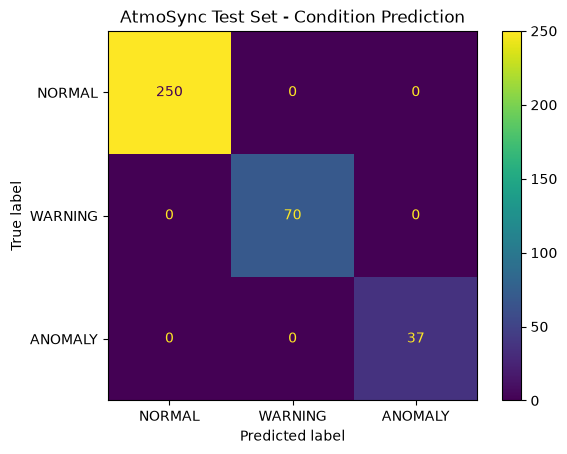

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["NORMAL", "WARNING", "ANOMALY"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["NORMAL", "WARNING", "ANOMALY"]
)

disp.plot()
plt.title("AtmoSync Test Set - Condition Prediction")
plt.show()

In [88]:
# Load the trained AtmoSync model

import joblib
import pandas as pd
import matplotlib.pyplot as plt

pipeline = joblib.load("../models/condition_prediction_model.pkl")

print("Model loaded successfully.")
print(pipeline)

Model loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['commodity',
                                                   'container_id']),
                                                 ('numerical', 'passthrough',
                                                  ['temperature', 'humidity',
                                                   'vibration', 'hour',
                                                   'day_of_week'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])


In [89]:
# Feature importance analysis

model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance["importance_percent"] = (
    feature_importance["importance"] * 100
)

feature_importance.head(15)

,feature,importance,importance_percent
0,numerical__vibration,0.580608,58.060752
1,numerical__temperature,0.206556,20.655636
2,numerical__humidity,0.175880,17.587987
3,numerical__hour,0.007645,0.764506
4,categorical__commodity_Banana,0.006316,0.631610
5,categorical__commodity_Avocado,0.005385,0.538499
6,categorical__commodity_Mango,0.003384,0.338396
7,categorical__commodity_Tomato,0.003123,0.312301
8,categorical__container_id_CONT_004,0.002366,0.236645
9,categorical__container_id_CONT_005,0.002257,0.225722


In [90]:
# Save feature importance results

feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [91]:
# Sensor statistics by actual condition

sensor_by_condition = df.groupby("condition")[
    ["temperature", "humidity", "vibration"]
].agg(["mean", "min", "max"])

sensor_by_condition

temperature                humidity                vibration        \
                 mean   min    max       mean    min     max      mean   min   
condition                                                                      
ANOMALY     11.248043 -1.98  20.93  84.195109  60.16  100.00  0.476033  0.35   
NORMAL      11.210881  5.05  14.00  89.365749  85.00   94.99  0.125180  0.05   
WARNING     11.279347  2.02  16.93  83.700114  60.02  100.00  0.276676  0.20   

                 
            max  
condition        
ANOMALY    0.60  
NORMAL     0.20  
WARNING    0.35

In [92]:
# Average sensor values by condition

sensor_means = df.groupby("condition")[
    ["temperature", "humidity", "vibration"]
].mean()

sensor_means

,temperature,humidity,vibration
condition,,,
ANOMALY,11.248043,84.195109,0.476033
NORMAL,11.210881,89.365749,0.125180
WARNING,11.279347,83.700114,0.276676


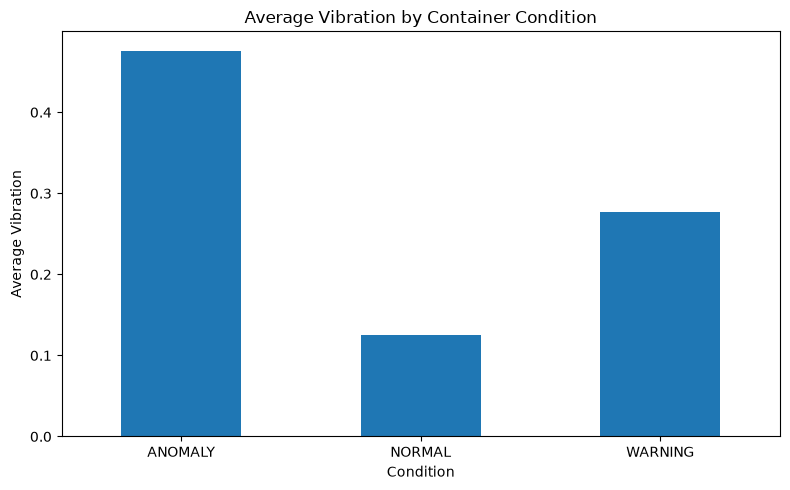

In [93]:
# Vibration by condition

plt.figure(figsize=(8, 5))

sensor_means["vibration"].plot(kind="bar")

plt.xlabel("Condition")
plt.ylabel("Average Vibration")
plt.title("Average Vibration by Container Condition")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

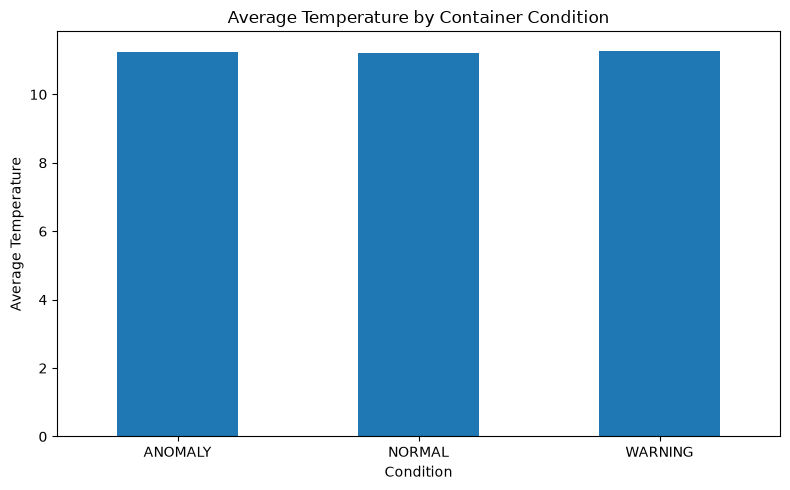

In [94]:
# Temperature by condition

plt.figure(figsize=(8, 5))

sensor_means["temperature"].plot(kind="bar")

plt.xlabel("Condition")
plt.ylabel("Average Temperature")
plt.title("Average Temperature by Container Condition")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

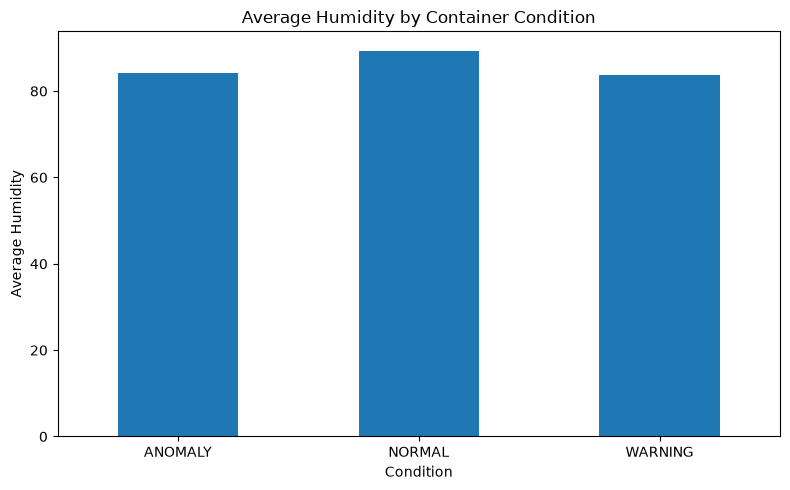

In [95]:
# Humidity by condition

plt.figure(figsize=(8, 5))

sensor_means["humidity"].plot(kind="bar")

plt.xlabel("Condition")
plt.ylabel("Average Humidity")
plt.title("Average Humidity by Container Condition")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [96]:
# Save sensor statistics by condition

sensor_by_condition.to_csv(
    "../data/processed/sensor_statistics_by_condition.csv"
)

sensor_means.to_csv(
    "../data/processed/sensor_means_by_condition.csv"
)

print("Sensor analysis files saved successfully.")

Sensor analysis files saved successfully.


In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate test-set metrics

accuracy_test = accuracy_score(y_test, y_test_pred)

precision_test = precision_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

recall_test = recall_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

f1_test = f1_score(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

# Final Day 9 summary

print("========== ATMOSYNC DAY 9 SUMMARY ==========")

print(f"Training records: {len(X_train)}")
print(f"Testing records: {len(X_test)}")

print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test Precision: {precision_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")
print(f"Test F1 Score: {f1_test:.4f}")

print(f"Anomaly Recall: {anomaly_recall_test:.4f}")

print(f"Incorrect predictions: {len(test_errors)}")

print(
    f"Test error rate: "
    f"{len(test_errors) / len(X_test) * 100:.2f}%"
)

print(f"Mean test confidence: {y_test_confidence.mean():.4f}")
print(f"Minimum test confidence: {y_test_confidence.min():.4f}")

print("\nTop 3 Features:")

display(
    feature_importance[
        ["feature", "importance_percent"]
    ].head(3)
)

========== ATMOSYNC DAY 9 SUMMARY ==========
Training records: 1428
Testing records: 357
Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1 Score: 1.0000
Anomaly Recall: 1.0000
Incorrect predictions: 0
Test error rate: 0.00%
Mean test confidence: 0.9952
Minimum test confidence: 0.8450

Top 3 Features:


,feature,importance_percent
0,numerical__vibration,58.060752
1,numerical__temperature,20.655636
2,numerical__humidity,17.587987


In [99]:
# Save final Day 9 evaluation summary

evaluation_summary = pd.DataFrame({
    "metric": [
        "Training Records",
        "Testing Records",
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Anomaly Recall",
        "Incorrect Test Predictions",
        "Test Error Rate",
        "Mean Test Confidence",
        "Minimum Test Confidence",
        "Low Confidence Predictions (<90%)"
    ],
    "value": [
        len(X_train),
        len(X_test),
        accuracy_test,
        precision_test,
        recall_test,
        f1_test,
        anomaly_recall_test,
        len(test_errors),
        len(test_errors) / len(X_test) * 100,
        y_test_confidence.mean(),
        y_test_confidence.min(),
        len(low_confidence_test)
    ]
})

evaluation_summary.to_csv(
    "../data/processed/model_evaluation_summary.csv",
    index=False
)

print("Final Day 9 evaluation summary saved successfully.")

Final Day 9 evaluation summary saved successfully.
